### Generate data AWGN channel

In [1]:
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import pickle
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('ggplot')
import sys
import numpy

### SETUP COPULA
# sys.path.append("D:/NPC")
#sys.path.append("C:/Users/alessandro/Documents/GitHub/NPC")
#sys.path.append("/n/data2/hms/neurobio/harvey/Houman/NPC/NPC")
sys.path.append("/Users/safaai/Library/CloudStorage/OneDrive-CompTech/Houman_Work/NPC")

import tensorflow as tf
#gpu_devices = tf.config.experimental.list_physical_devices('GPU')
#device = gpu_devices[0]
# tf.config.experimental.set_memory_growth(device, True)
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import sys
from classes.objects import *
from vine_tree.tree_op import *

from scipy import stats
import pickle

###########

from param.generate_rvine import *
from param.margin_fit import *
from param.margin_op import *
from param.copula_fit import *
from param.cond_copula import *
from pre_proc.preparation import prep_cop
from pred.prediction import*
from sampling.vine_sample import *
from info.info_estimation import vine_entropy

In [2]:
def sample_AWGN_channel(batch_size, dim, SIGNAL_NOISE = 0.5, SIGNAL_POWER = 2):
    """Simple additive white Gaussian noise channel"""
    x_sample = tf.random.normal((batch_size, dim), stddev = np.sqrt(SIGNAL_POWER))
    y_sample = x_sample + tf.random.normal((batch_size, dim), stddev = np.sqrt(SIGNAL_NOISE))   
    
    return tf.cast(x_sample, tf.float32), tf.cast(y_sample, tf.float32)

In [3]:
### THIS IS TO GENERATE THE DATA BUT IF YOU ALREADY LOADED IS NOT NECESSARY

batch_size = 1000
var1, var2 = sample_AWGN_channel(batch_size, 8)
# print(y.shape)

var1 = np.array(var1)
var2 = np.array(var2)

data = np.array([var1,var2]).transpose(1,0,2)
data = data.reshape(data.shape[0],-1)
print(data.shape)

# data = np.array([var1.flatten(),var2.flatten()]).T
# print(data.shape)

(1000, 16)


### Fit copula var1-var2

In [4]:
################################ -  DEFINE THE VINE FOR FITTING - ####################################

### When defining the vine object
### If you use "r-vine", you have to add 'method' and 'r_matrix'
### E.g. using:
### r_matrix, ind_vine, nodes, matrix_edges = prepare_vine(vine_type, dim)
### and:
### vine = vine_obj_bin(vine_type, families, vine_total_dim, margin_vine, knots, method, r_matrix)

vine_type = "c-vine"
method = 'matrix' #'matrix' 'optimal'
families = "kercop"
knots = 100

vine_total_dim = data.shape[1]

#### Generate random matrix
        
##### RANDOM R-MATRIX
r_matrix, ind_vine, nodes, E = random_r_matrix_gen(vine_total_dim)
print(r_matrix)

E, ind_vine, nodes, matrix_edges = prepare_regular(r_matrix)
print('matrix_edges',matrix_edges)

## Define the margins
margin_vine = []
for i in range(0,vine_total_dim,1):
    mar_p = margin_obj('norm', [0,1], True)
    margin_vine.append(mar_p)
    
# vine = vine_obj_bin(vine_type, families, vine_total_dim, margin_vine, knots)

vine = vine_obj_bin(vine_type, families, vine_total_dim, margin_vine, knots, method, r_matrix)

######### IF YOU WANT TO LOAD THE SAVED VINE --> Put load_pickle = True
load_pickle = False

if load_pickle:
    pickle_in = open("awgn_vine_16","rb")
    dict_save = pickle.load(pickle_in)
    # print(dict_save.keys())
    vine_copulas = dict_save["vine_copulas"]
    data = dict_save["data"]
    r_matrix = dict_save["r_matrix"]
    vine_depth = 16

    ## Here you load the copulas in the vine
    vine.copulas = vine_copulas
    vine.r_matrix = r_matrix
    vine.vine_depth = vine_depth

[[ 3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 6 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  6 10  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 8  1  6  6  0  0  0  0  0  0  0  0  0  0  0  0]
 [10  8  1 14  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 9 10  8 16 14  8  0  0  0  0  0  0  0  0  0  0]
 [ 2  9  9 11 16 14  9  0  0  0  0  0  0  0  0  0]
 [12  2  2  4 11 16 14  2  0  0  0  0  0  0  0  0]
 [ 5 12 12  8  4 11 16 14 12  0  0  0  0  0  0  0]
 [15  5  5  9  8  4 11 16 14  5  0  0  0  0  0  0]
 [14 15 15  5  9  2  4 11 16 14 14  0  0  0  0  0]
 [ 7 14 16 15  5 12  2  4 11 16 15 16  0  0  0  0]
 [ 4  7 11  2 15 15 12  5  4 11 16 15 11  0  0  0]
 [16  4  7  1  2  7 15 15  5  4 11  7 15  4  0  0]
 [11 16  4  7 12  9  7  7 15 15  7  4  7 15 15  0]
 [13 11 14 12  7  5  5 12  7  7  4 11  4  7  7  7]]
nodes:
[ 7 15  4 11 16 14  5 12  2  9  8  1  6 10 13  3]
edges:
['(7,15)', '(7,4)', '(4,11)', '(11,16)', '(4,14)', '(7,5)', '(7,12)', '(12,2)', '(5,9)', '(5,8)', '(7,1)', '(12,6)', '(

In [5]:
################################ -  VINE FITTING - ####################################
### Vine fitting instructions

# General parameters:
# - parallel: True or False           (Fit in parallel each level)
# - binning: True or False            (It can be True only if parallel is False)
# - param: True or False              (Parametric or Non-parametric)
# - vine_depth: any                   (Max level of vine to fit)
# - Fitted: True or False             (If the vine was already fitted, recompute some needed variables)

# Parametric parameters:
# - param_families: ["ind","gaussian","student","clayton","claytonrot90"]   (Decide which parametric families to fit)

# Non-parametric parameters:
# - opt_method: 'LL1' or 'LL2'

# Binning parameters:
# - n_bin: any                        (Number of bins)

### Parameters

param = False
binning = False
n_bins = 3
parallel = True

if binning:
    parallel = False

### Make data divisible for bins and k-fold

x = np.array(data,np.float32)

if binning == True:
    if param == False:
        exc = x.shape[0] % (n_bins*5) #tf.math.floormod(tf.shape(x)[0],n_bin*5)
    else:
        exc = x.shape[0] % n_bins #tf.math.floormod(tf.shape(x)[0],n_bin)
    x = x[:x.shape[0]-exc,:]
else:
    if param == False:
        exc = x.shape[0] % 5 #tf.math.floormod(tf.shape(x)[0],5)
        x = x[:x.shape[0]-exc,:]

### Prepare copula

sort_n = 'rand'
e = prep_cop(x, vine, sort_n)
print(e)

### FITTING
# Add parameters in a dictionary
vine_depth_fit = 10

gen_dict = {'parallel':parallel, 'binning':binning, 'param':param, 'vine_depth':vine_depth_fit, 'fitted':False}  #vine_depth
par_dict = {'param_families':["ind","gaussian"]}  #["ind","gaussian","student","clayton","claytonrot90"]
npc_dict = {'opt_method':'LL1','batch_paral':3}
bin_dict = {'n_bin':n_bins}

save_vine = False

vine.fit(x,gen_dict,npc_dict,par_dict,bin_dict)

if save_vine:
    dict_save = {'vine_copulas': vine.copulas, 'r_matrix': vine.r_matrix, 'data': x}
    pickle_out = open("awgn_16_d_vine_10_500","wb")
    pickle.dump(dict_save,pickle_out)
    pickle_out.close()

[[ 0.46311042 -1.1916528   0.45174745 ... -1.0328543  -1.0220994
   0.76228225]
 [ 2.4033601   0.408618   -2.1306705  ... -4.1336102  -1.2870355
   1.6123405 ]
 [-0.5742385  -4.279186    1.2810602  ... -0.06460941 -2.9414644
  -0.63311344]
 ...
 [ 0.21987027 -0.22785181  1.4314278  ... -1.4400302  -0.30829436
  -0.48879793]
 [-1.3244808  -0.7582045  -1.793095   ...  0.10025063  0.69973403
  -1.3505439 ]
 [-1.3618373   0.17657247 -0.7636495  ...  0.707463   -2.979322
  -1.2626979 ]]
time_fit: 39.061947
time_fit: 61.255679457999996
time_fit: 33.46321829200001
time_fit: 12.969653916999988
time_fit: 20.280952083000017
time_fit: 26.606546791
time_fit: 12.973483458000004
time_fit: 24.65616537500003
time_fit: 33.29271950000003
time_fit: 20.778621541999996
time_fit: 4.0967217919999825
time_fit: 18.260470416000032
time_fit: 15.953803375000007
time_fit: 17.446611375000032
time_fit: 20.957532166999954
time_fit: 12.542816707999975
time_fit: 17.26888395900005
time_fit: 16.637441249999995
time_fit: 

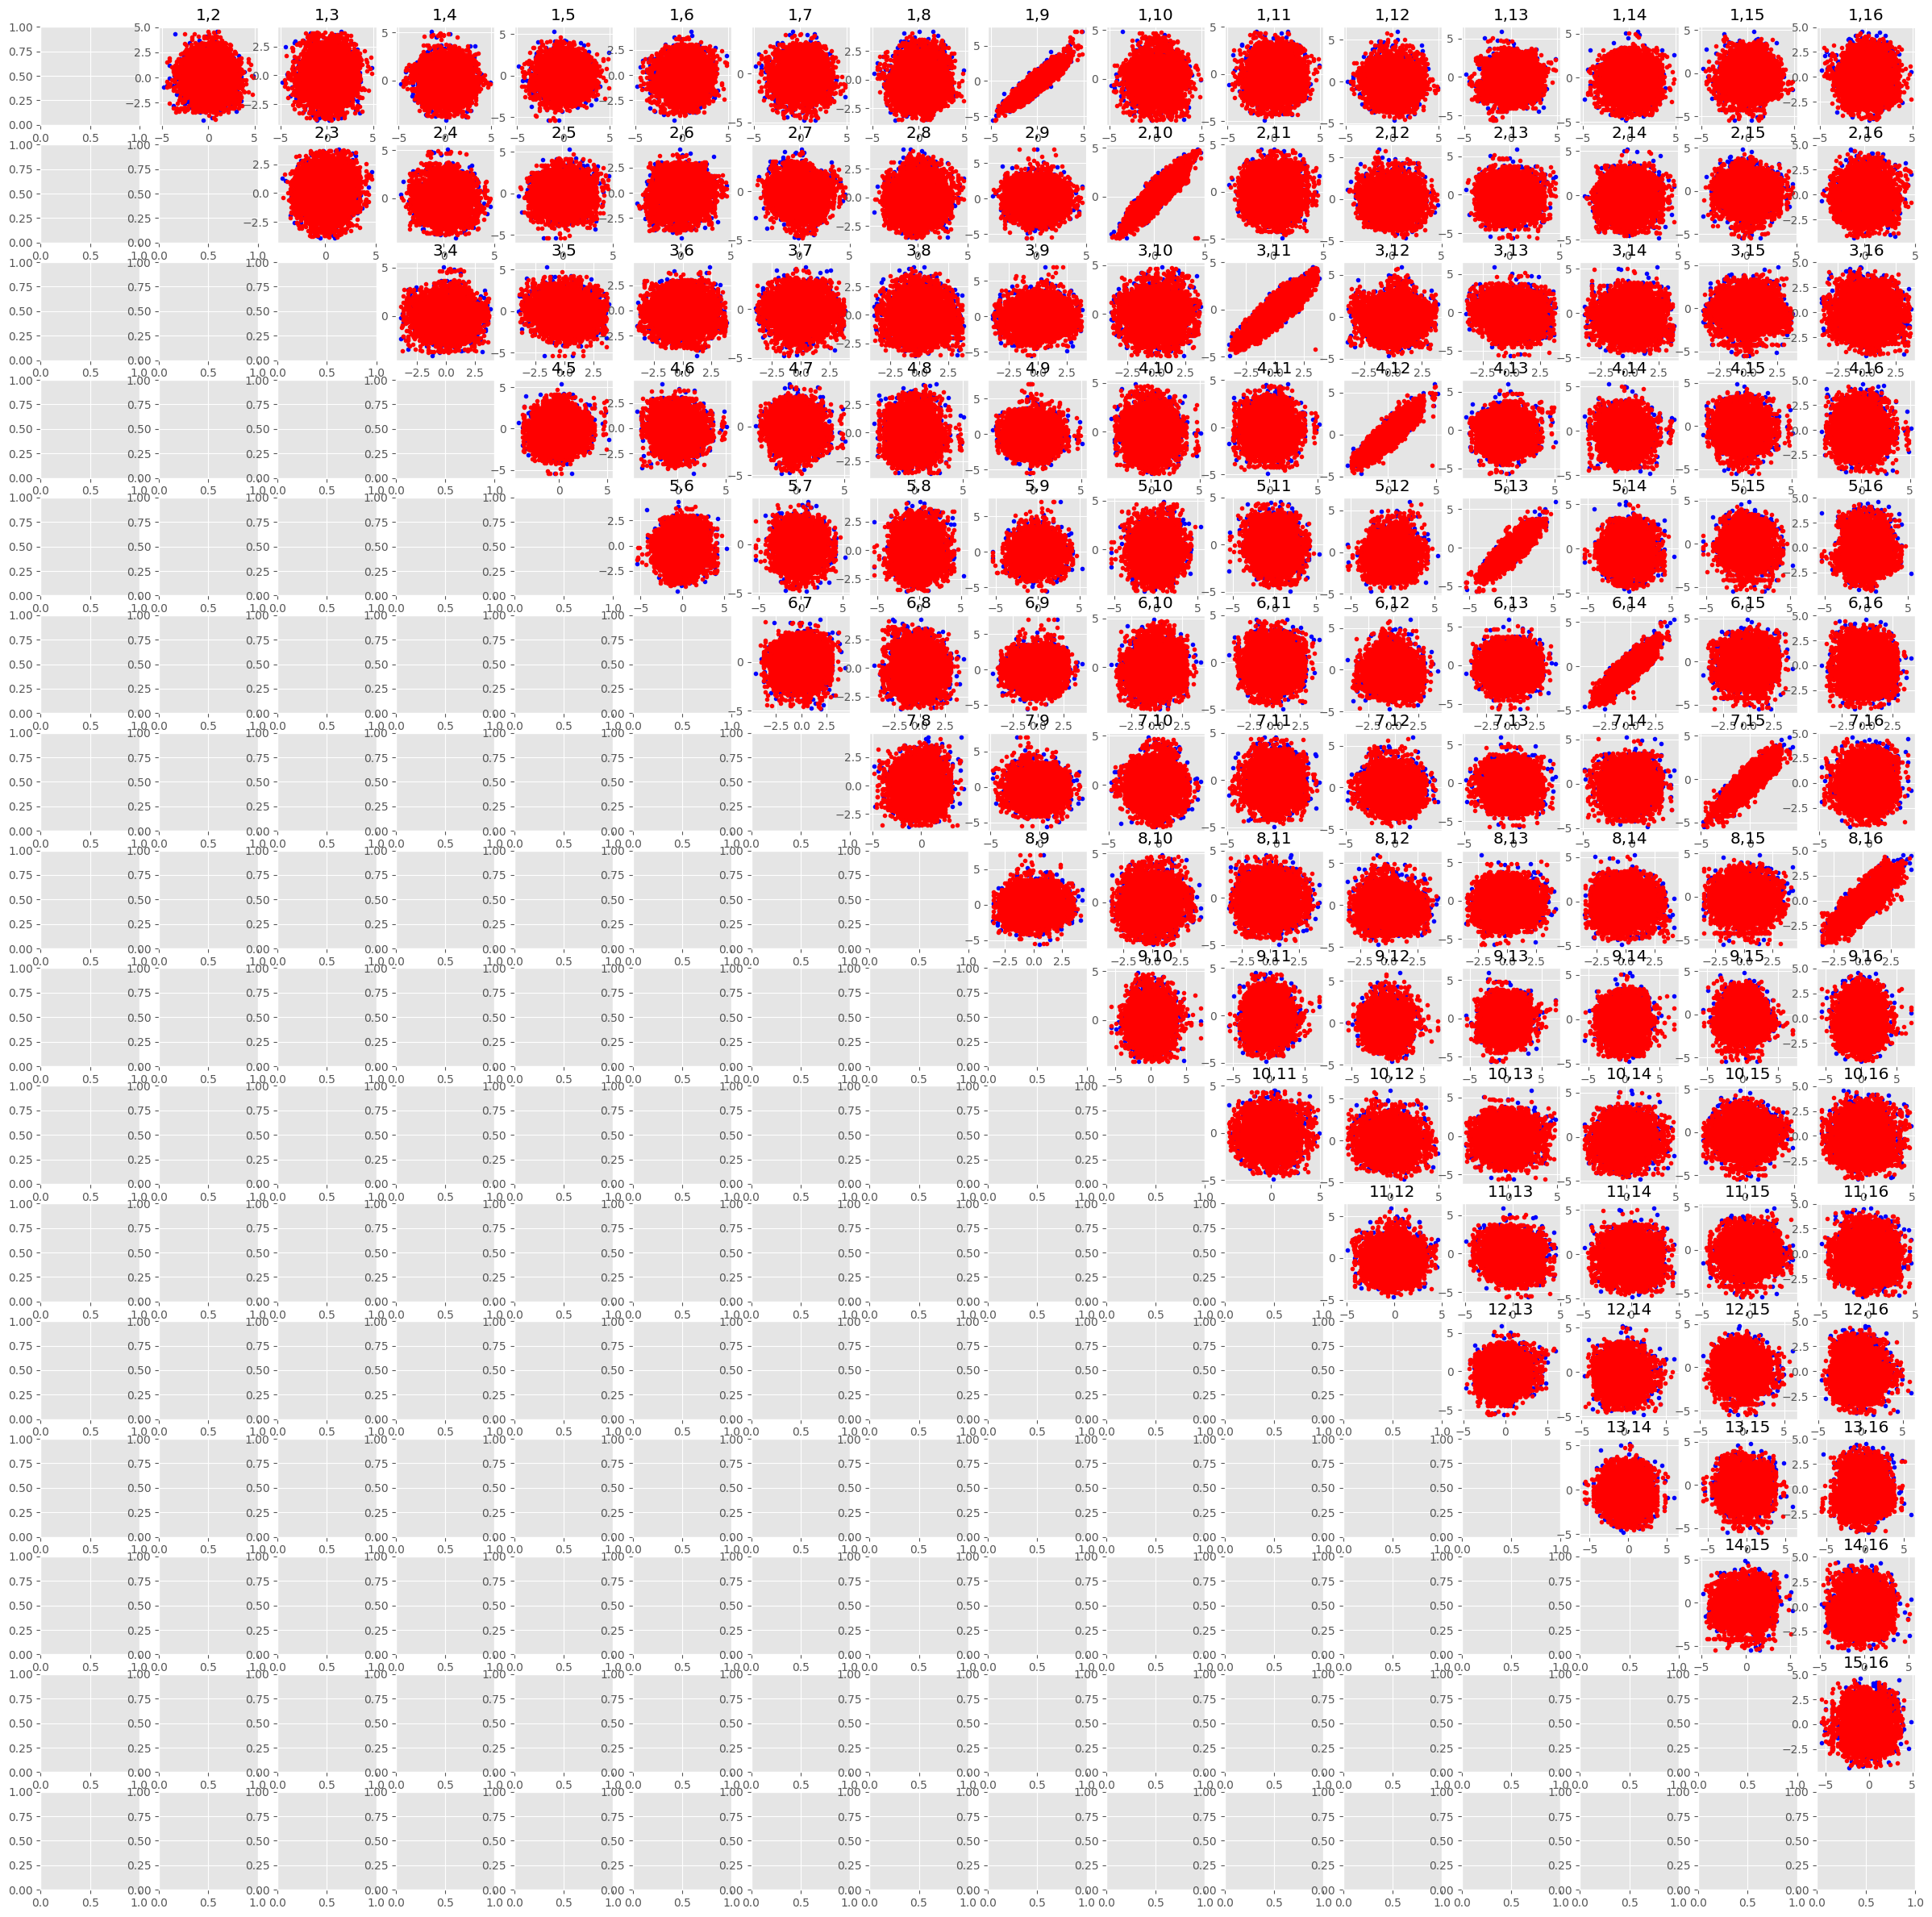

In [6]:
cases = 5000
sample, _, _, _ = vine_copula_sample(vine,cases)

fig, axs = plt.subplots(vine.n_cop, vine.n_cop,figsize=(30,30))
for i in range(0,vine.n_cop,1):
    for j in range(i+1,vine.n_cop,1):
        axs[i,j].plot(data[:,i],data[:,j],'b.')    
        axs[i,j].plot(sample[:,i],sample[:,j],'r.')    
        axs[i,j].set_title(str(i+1)+","+str(j+1))

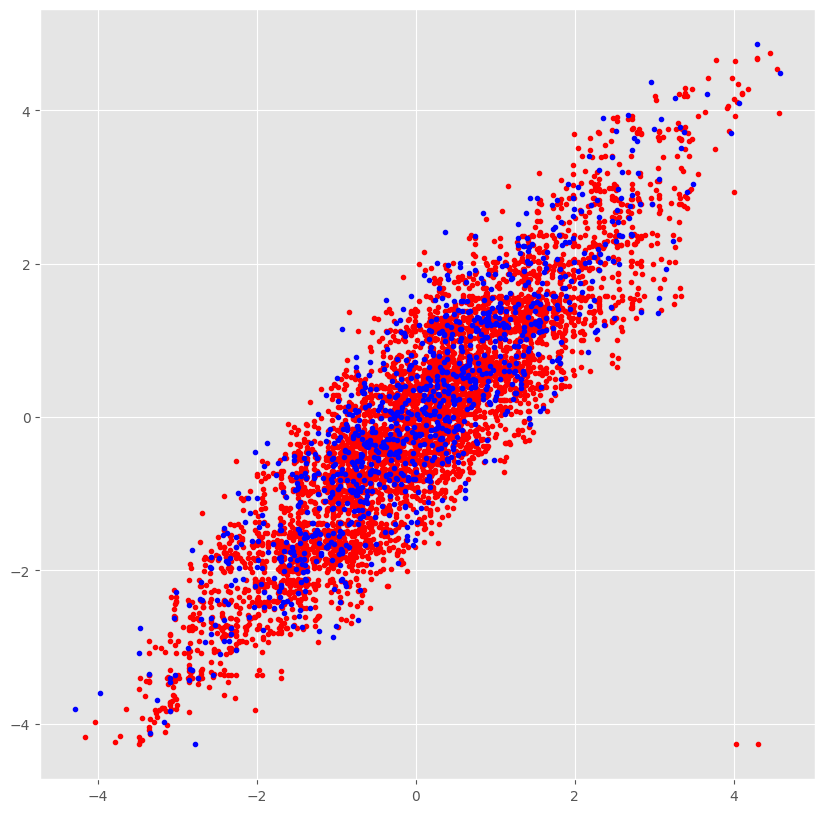

In [7]:
fig, axs = plt.subplots(1,1,figsize=(10,10))
axs.plot(sample[:,1],sample[:,9],'r.')
axs.plot(data[:,1],data[:,9],'b.')